# Stock Price Prediction Model

### 1. **Data Collection**
The dataset used for this project was obtained from finance.yahoo.com containing historical stock prices of a particular company. The data included features such as Open, High, Low, Close, Volume, and Date.

### 2. **Exploratory Data Analysis (EDA)**
EDA was conducted to understand the structure and distribution of the data. The following steps were performed:
- **Missing Value Handling:** Checked for and imputed any missing values.
- **Data Visualization:** Plotted historical stock prices, moving averages, and volatility trends.
- **Feature Engineering:** Created new features such as moving averages and normalized values for better model performance.

### 3. **Data Preprocessing**
To prepare the data for the machine learning model, the following steps were undertaken:
- **Scaling:** The stock prices were normalized using MinMaxScaler to improve model convergence.
- **Data Splitting:** The dataset was divided into training and testing sets.
- **Reshaping Data:** The data was reshaped into a 3D format to be used in an LSTM model.

### 4. **Model Development**
A deep learning model using Keras and TensorFlow was implemented. The architecture consists of:
- **LSTM Layers:** Used Long Short-Term Memory (LSTM) layers to capture temporal dependencies in stock prices.
- **Dense Layers:** Final dense layers were added to output stock price predictions.

### 5. **Model Training & Optimization**
- The model was compiled using the **Adam optimizer** and **Mean Squared Error (MSE)** as the loss function.
- The model was trained for multiple epochs with batch normalization to improve stability.

### 6. **Model Evaluation**
The model performance was evaluated using:
- **Root Mean Squared Error (RMSE):** To measure the accuracy of predictions.
- **Comparison with Actual Prices:** The predicted stock prices were plotted against actual prices.
- **Residual Analysis:** Examined the difference between predicted and actual values to detect patterns.

### 7. **Results & Visualization**
- The model's predictions were visualized to analyze the trend-following capability.
- A comparison of predicted vs. actual stock prices was made to assess forecasting accuracy.

### 8. **Conclusion & Future Enhancements**
- The model showed promising results in predicting stock prices based on historical data.
- Future improvements could include incorporating external market factors, news sentiment analysis, and alternative deep learning architectures such as transformers.

### 9. **Model Deployment Using Streamlit**
After training and evaluating the model, it was deployed as an interactive web application using Streamlit. The deployment process involved:

Building a Streamlit App: Created a user-friendly interface where users can input data and visualize stock price predictions.
Loading the Trained Model: The trained LSTM model was loaded using TensorFlow/Keras for real-time inference.
User Interaction: The app allows users to select a stock, input features, and get predictions.
Data Visualization: Displayed stock price trends, predictions vs. actual values, and interactive plots using Matplotlib and Seaborn.





In [908]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [635]:
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM

In [639]:
##Defining start and end date
end = datetime.now()
start = datetime(end.year-20,end.month,end.day)

In [707]:
stock = "GOOG"
input_data = yf.download(stock,start,end)

[*********************100%***********************]  1 of 1 completed


## Performing EDA

In [709]:
input_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,5032.000000,5032.000000,5032.000000,5032.000000,5.032000e+03
mean,50.188880,50.699039,49.665655,50.168230,1.044416e+08
std,48.093798,48.601863,47.587523,48.065835,1.346495e+08
min,4.337868,4.422399,4.277878,4.345552,1.584340e+05
25%,13.464147,13.615237,13.330284,13.502136,2.625100e+07
50%,28.550022,28.767025,28.338850,28.587489,4.880879e+07
75%,67.483501,68.240084,66.972057,67.506504,1.281144e+08
max,207.473633,208.462496,204.027547,204.267279,1.650833e+09


In [711]:
input_data.shape

(5032, 5)

In [713]:
google_data.isna().sum()

Price              Ticker
Close              GOOG        0
High               GOOG        0
Low                GOOG        0
Open               GOOG        0
Volume             GOOG        0
MA_for_250_days              249
MA_for_100_days               99
Percentage_Change              1
dtype: int64

In [717]:
input_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5032 entries, 2005-03-11 to 2025-03-11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   5032 non-null   float64
 1   (High, GOOG)    5032 non-null   float64
 2   (Low, GOOG)     5032 non-null   float64
 3   (Open, GOOG)    5032 non-null   float64
 4   (Volume, GOOG)  5032 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 235.9 KB


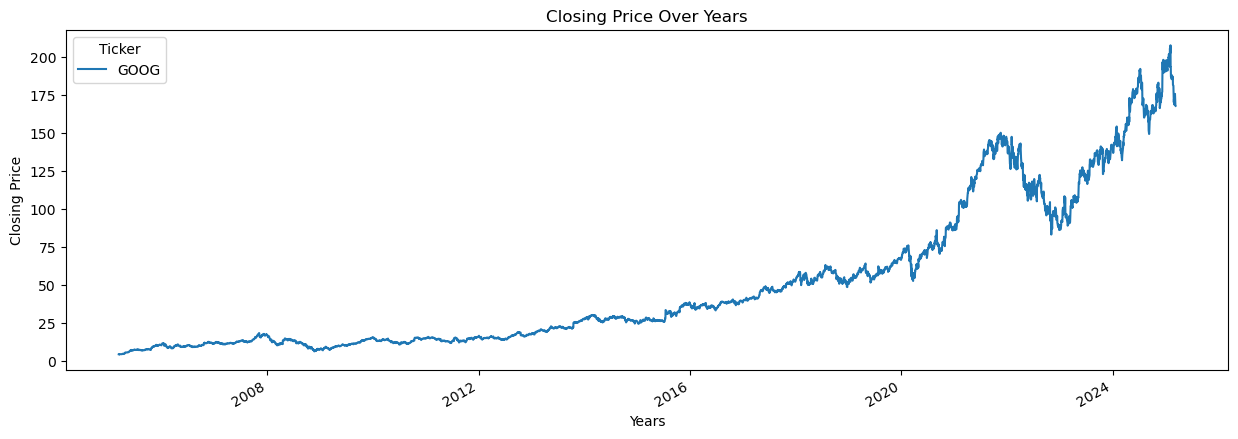

In [718]:

input_data['Close'].plot(figsize=(15,5))
plt.title("Closing Price Over Years")
plt.xlabel("Years")
plt.ylabel("Closing Price")
plt.show()

In [720]:
## Defining a function to plot values across different dimensions

def plot_graph(values,column_name):
    values.plot(figsize = (15,5))
    plt.title(f"{column_name} Price Over Years")
    plt.xlabel("Years")
    plt.ylabel(f"{column_name[0]} Price")
    plt.show()

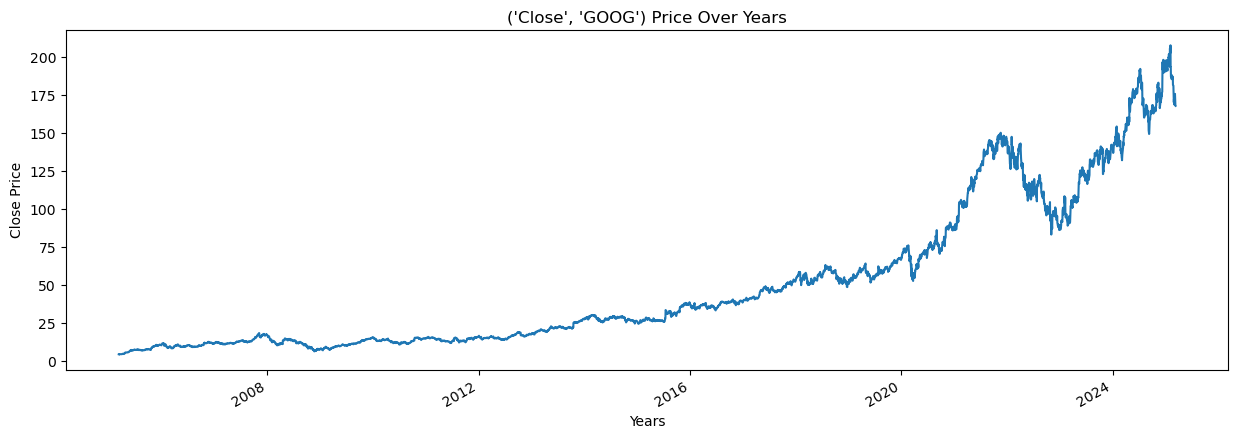

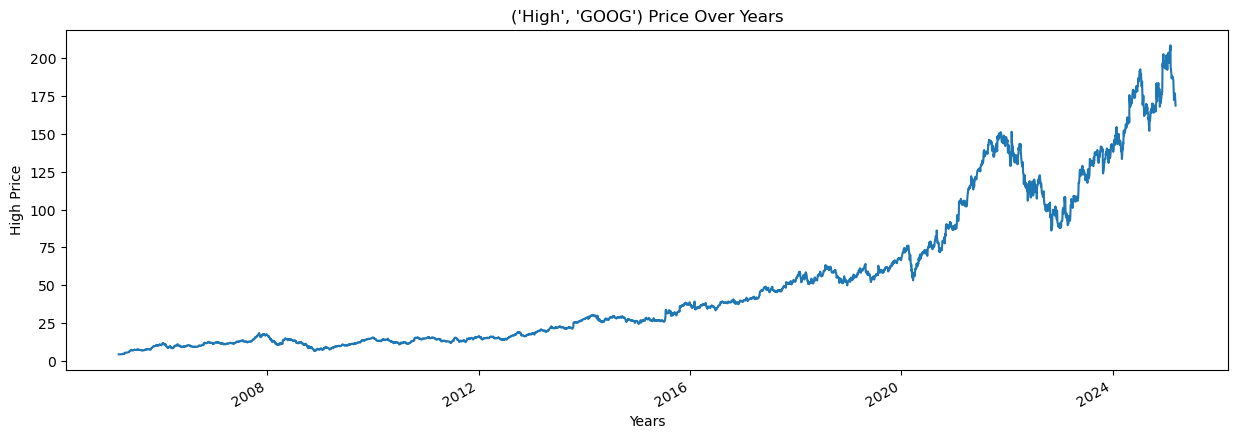

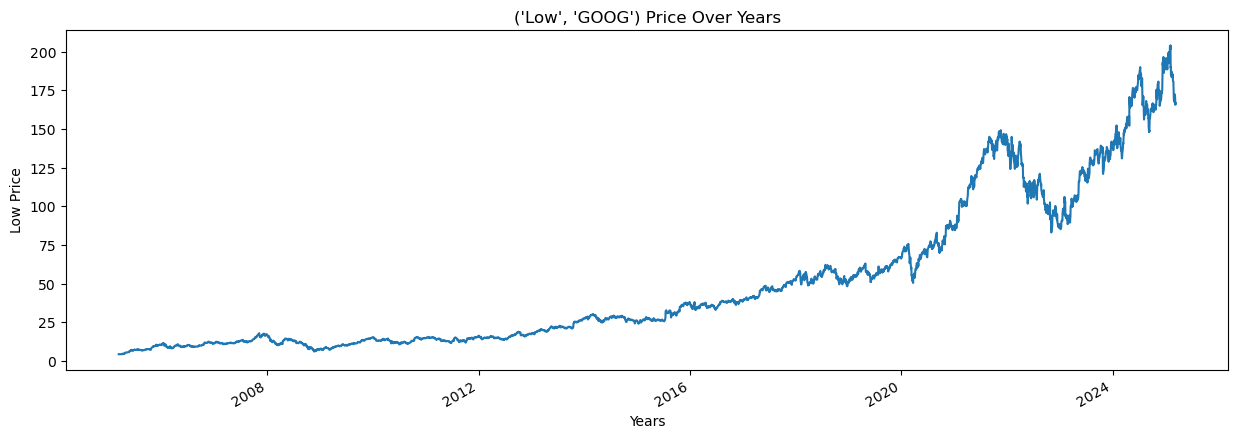

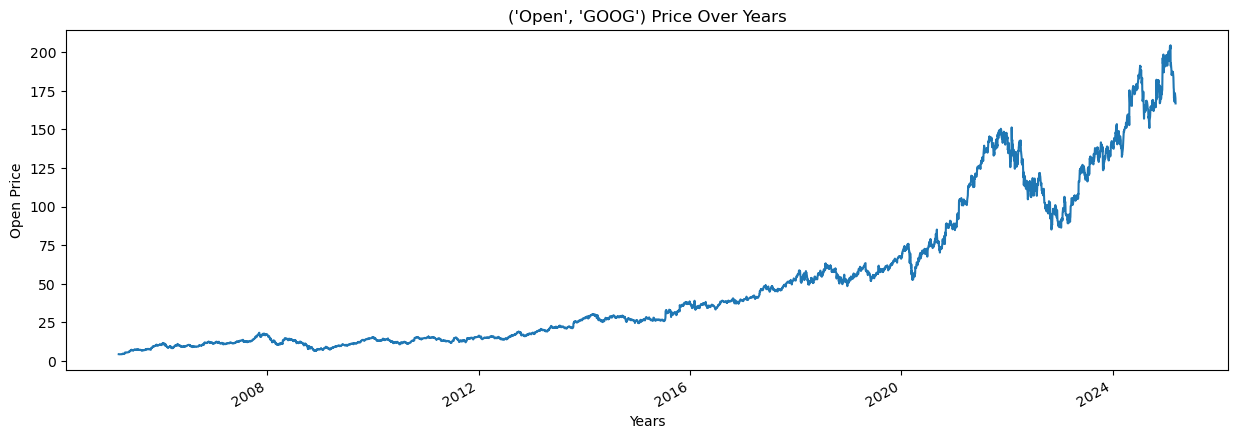

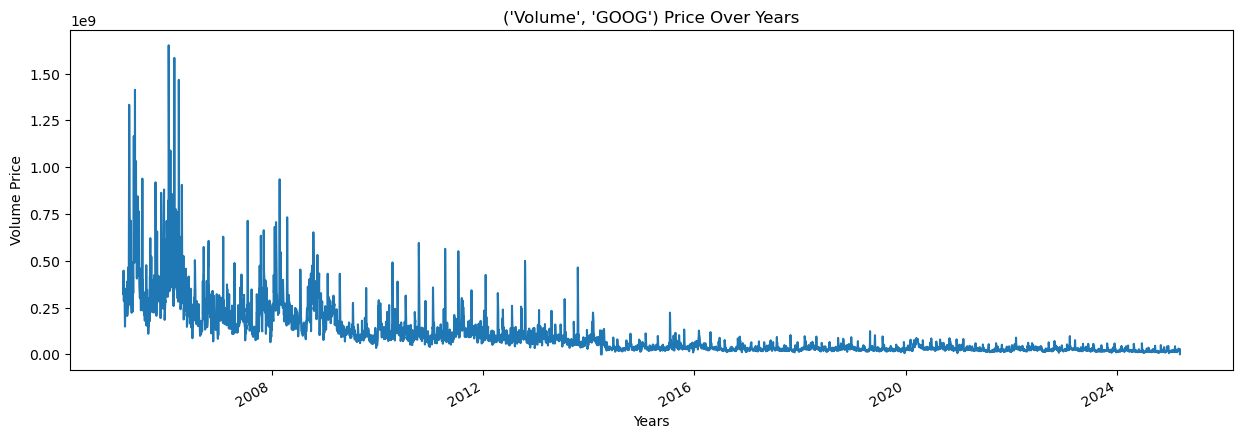

In [723]:
for columns in input_data.columns:
    plot_graph(input_data[columns],columns)

## Feature Engineering 

In [675]:
for i in range(2005,2026):
    print(i,list(input_data.index.year).count(i))

2005 205
2006 251
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 252
2025 45


In [726]:
input_data["MA_for_250_days"] = input_data["Close"].rolling(250).mean()

In [728]:
input_data

Price,Close,High,Low,Open,Volume,MA_for_250_days
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,
Date,,,,,,
2005-03-11,4.407525,4.485611,4.391412,4.472969,322335682,NaN
2005-03-14,4.337868,4.422399,4.277878,4.420664,447535208,NaN
2005-03-15,4.427605,4.462061,4.318531,4.345552,418446584,NaN
2005-03-16,4.352990,4.427605,4.338364,4.380257,285317446,NaN
2005-03-17,4.444461,4.453137,4.357947,4.390917,331662510,NaN
...,...,...,...,...,...,...
2025-03-05,174.790878,175.550008,170.735486,172.123918,18848000,172.685899
2025-03-06,174.011765,176.528886,172.311690,172.353650,19082400,172.854205


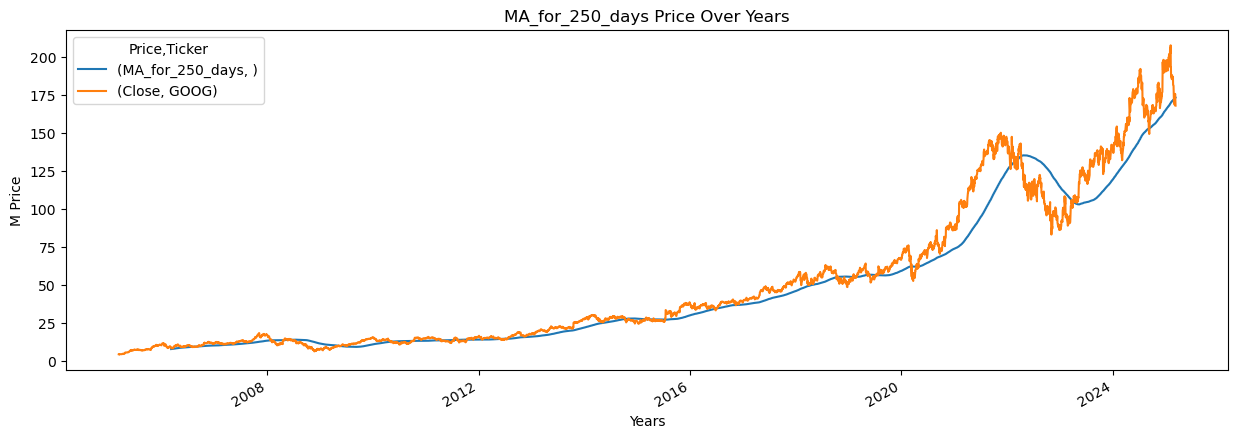

In [734]:
plot_graph(google_data[['MA_for_250_days','Close']],'MA_for_250_days')

In [736]:
input_data["MA_for_100_days"] = input_data.Close.rolling(100).mean()

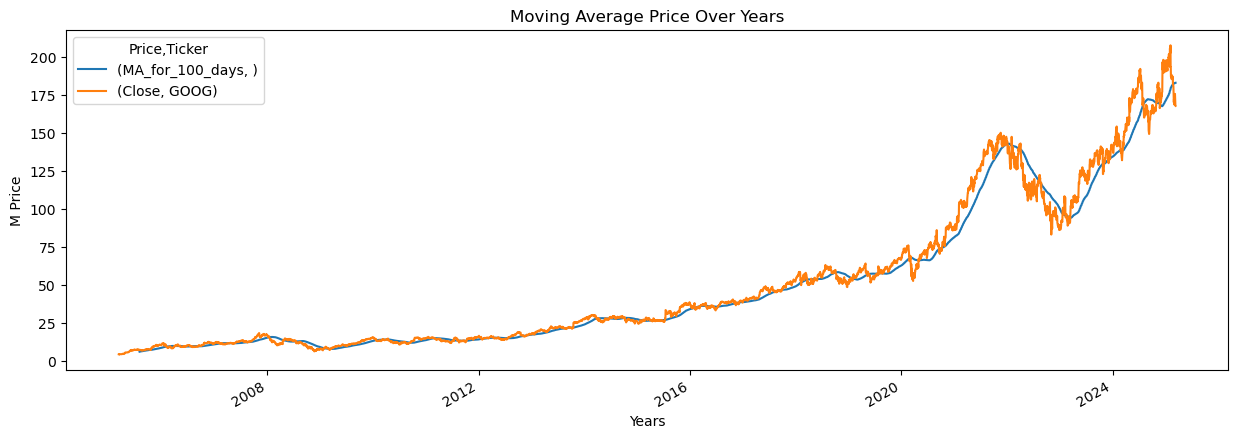

In [738]:
plot_graph(input_data[["MA_for_100_days","Close"]],"Moving Average")

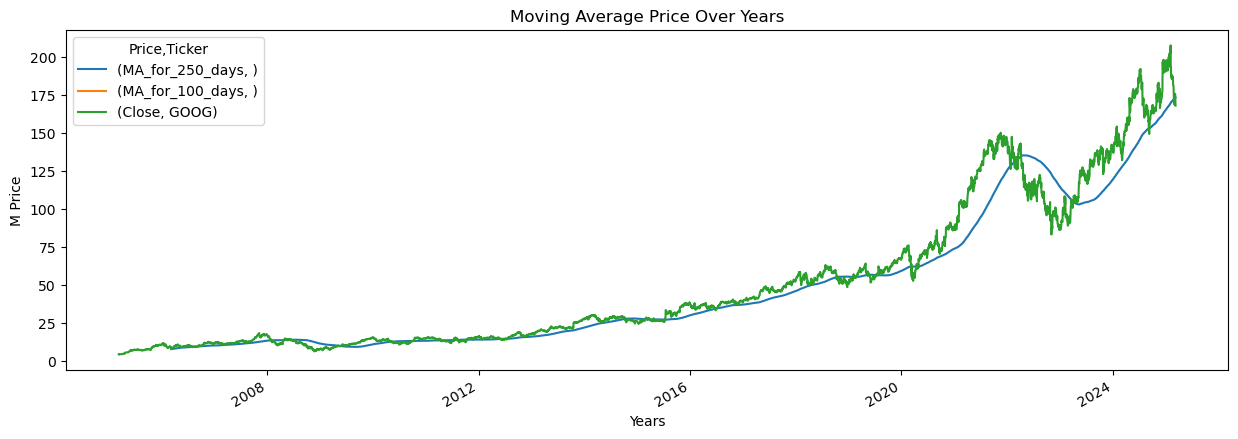

In [740]:
plot_graph(google_data[["MA_for_250_days","MA_for_100_days","Close"]],"Moving Average")

In [749]:
input_data['Percentage_Change'] = input_data.Close.pct_change()

In [757]:
input_data.head(100)

Price,Close,High,Low,Open,Volume,MA_for_250_days,MA_for_100_days,Percentage_Change
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,
Date,,,,,,,,
2005-03-11,4.407525,4.485611,4.391412,4.472969,322335682,NaN,NaN,NaN
2005-03-14,4.337868,4.422399,4.277878,4.420664,447535208,NaN,NaN,-0.015804
2005-03-15,4.427605,4.462061,4.318531,4.345552,418446584,NaN,NaN,0.020687
2005-03-16,4.352990,4.427605,4.338364,4.380257,285317446,NaN,NaN,-0.016852
2005-03-17,4.444461,4.453137,4.357947,4.390917,331662510,NaN,NaN,0.021013
...,...,...,...,...,...,...,...,...
2005-07-27,7.360667,7.392892,7.248372,7.380746,289798178,NaN,NaN,0.002837
2005-07-28,7.275639,7.372565,7.270185,7.372565,237912424,NaN,NaN,-0.011552


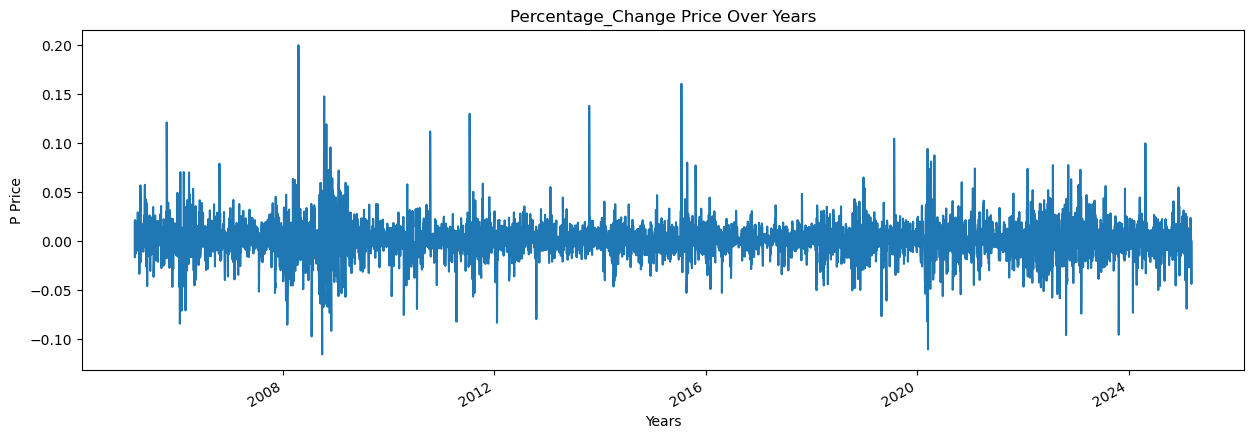

In [761]:
plot_graph(input_data["Percentage_Change"],"Percentage_Change")

## Data Preprocessing

In [771]:
Close_price = input_data[["Close"]]

In [773]:
max(Close_price.values),min(Close_price.values)

(array([207.47363281]), array([4.33786821]))

In [775]:
## Applying MinMax scaling for the stock prices to improve model convergence.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(Close_price) 

scaled_data

array([[3.42907853e-04],
       [0.00000000e+00],
       [4.41756093e-04],
       ...,
       [8.42845843e-01],
       [8.04743220e-01],
       [8.04103230e-01]])

In [777]:
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])

In [779]:
import numpy as np
x_data = np.array(x_data)
y_data = np.array(y_data)

In [768]:
x_data[0],y_data[0]

(array([[3.42907853e-04],
        [0.00000000e+00],
        [4.41756093e-04],
        [7.44378182e-05],
        [5.24733685e-04],
        [6.16260442e-04],
        [7.18772944e-04],
        [4.40537802e-04],
        [4.86905631e-04],
        [5.19855826e-04],
        [7.84663946e-04],
        [5.58904519e-04],
        [6.66294881e-04],
        [6.73616364e-04],
        [6.16260442e-04],
        [1.25693365e-03],
        [1.65720212e-03],
        [1.73652249e-03],
        [2.29054915e-03],
        [2.08187632e-03],
        [2.22587644e-03],
        [2.31495958e-03],
        [2.18926668e-03],
        [2.00865444e-03],
        [1.22154687e-03],
        [1.46194927e-03],
        [2.00255595e-03],
        [2.82017478e-03],
        [3.56701537e-03],
        [4.98137617e-03],
        [5.92346726e-03],
        [5.34014997e-03],
        [5.46584522e-03],
        [5.42557588e-03],
        [5.49269691e-03],
        [5.77214800e-03],
        [6.24807727e-03],
        [6.52997198e-03],
        [6.3

In [781]:
x_data.shape

(4932, 100, 1)

In [783]:
## Splitting the data into training and testing set

In [584]:
Xtrain , Xtest, ytrain , ytest = train_test_split(x_data,y_data,train_size=0.7 , shuffle=False)

In [784]:
Xtrain.shape,Xtest.shape,ytrain.shape,ytest.shape

((3451, 100, 1), (1480, 100, 1), (3451, 1), (1480, 1))

## Modelling the data using tensorflow

In [792]:
model = Sequential()
model.add(LSTM(128,return_sequences=True,input_shape=(Xtrain.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

C:\Users\dmmd1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [796]:
model.compile(optimizer='adam',loss = 'mean_squared_error')
model.fit(Xtrain,ytrain,batch_size=1,epochs=2)

Epoch 1/2
3451/3451 ━━━━━━━━━━━━━━━━━━━━ 156s 43ms/step - loss: 1.6503e-04
Epoch 2/2
3451/3451 ━━━━━━━━━━━━━━━━━━━━ 150s 43ms/step - loss: 4.6827e-05


In [797]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [798]:
predictions = model.predict(Xtest)

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step


In [799]:
predictions.shape

(1480, 1)

In [805]:
inverse_predictions = scaler.inverse_transform(predictions)

In [807]:
inverse_ytest = scaler.inverse_transform(ytest)

In [830]:
inverse_predictions.shape

(1480, 1)

In [828]:
inverse_ytest.shape

(1480, 1)

In [813]:
from sklearn.metrics import root_mean_squared_error

In [815]:
root_mean_squared_error(inverse_ytest,inverse_predictions)

3.9490363899408214

In [893]:
import pandas as pd 
plotting_data = pd.DataFrame({
    "original_test_data" : inverse_ytest.reshape(-1),
    "predicted_data":inverse_predictions.reshape(-1)
},index = input_data.index[len(Xtrain)+101:])

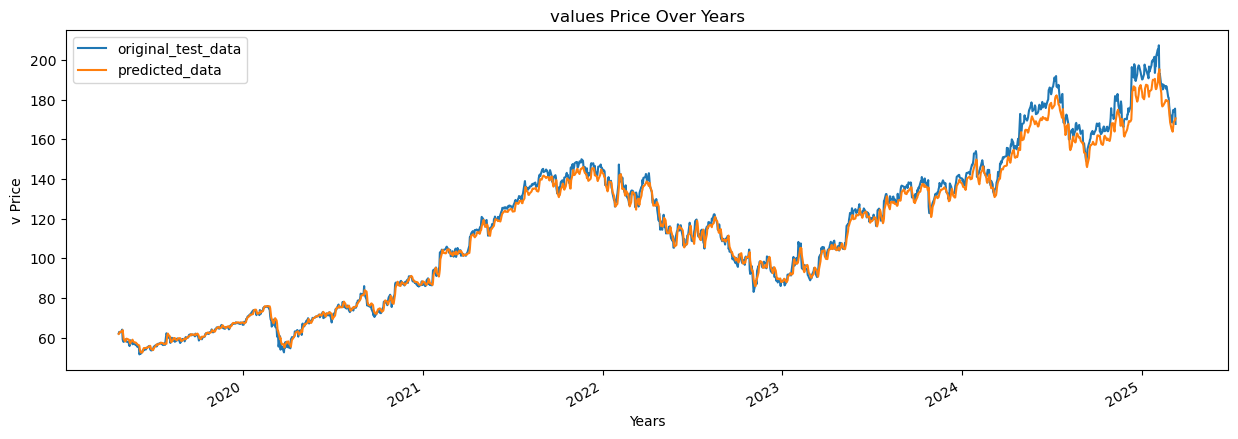

In [895]:
plot_graph(plotting_data,"values")

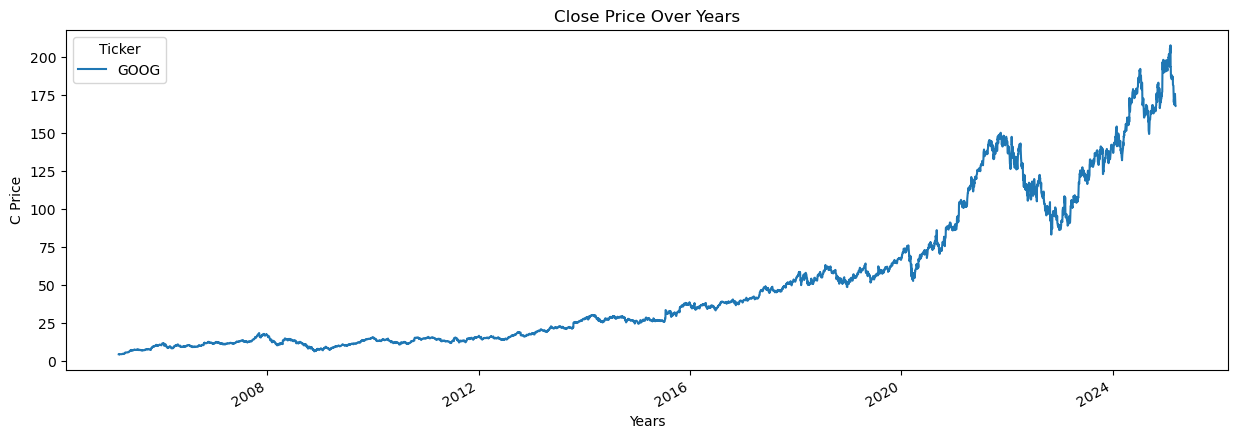

In [821]:
plot_graph(input_data["Close"],"Close")

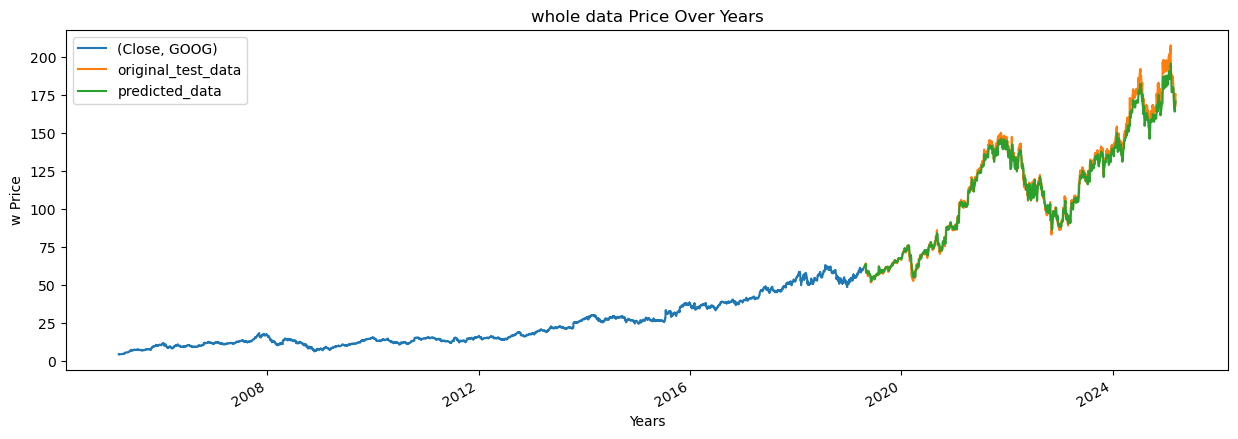

In [901]:
plot_graph(pd.concat([Close_price[:len(Xtrain)+101] ,plotting_data], axis=0), 'whole data')

In [903]:
model.save("Latest-Stock-Prediction-Model.keras")